# IMPORT LIBRARIES

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from matplotlib.dates import DateFormatter
from scipy.optimize import minimize # USE IN THE MODEL CALIBRATION

from google.colab import files
import zipfile
import os

from numba import njit
import warnings
warnings.filterwarnings('ignore')

##CAMELS-DATA

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

data_dir = "/content/drive/MyDrive/CAMELS_GB/"
start_date, end_date = '1990-01-01', '2014-12-31'

print("Loading, filtering, and aligning CSV files...\n")

# 1. Fast Load & Filter
df_pcp = pd.read_csv(f"{data_dir}pcp_mm.csv", index_col=0).loc[start_date:end_date]
df_pet = pd.read_csv(f"{data_dir}pet_mm.csv", index_col=0).loc[start_date:end_date]
df_q   = pd.read_csv(f"{data_dir}q_mmd_obs.csv", index_col=0).loc[start_date:end_date]

# 2. Fast Alignment
common_stations = sorted(list(set(df_pcp.columns) & set(df_pet.columns) & set(df_q.columns)))
df_pcp = df_pcp[common_stations]
df_pet = df_pet[common_stations]
df_q   = df_q[common_stations]

print(f"✅ Data aligned. Total common stations: {len(common_stations)}")

# ============================================
# Memory-Optimized Wrapper Classes
# ============================================
class SimpleArray:
    __slots__ = ['array']  # Prevents massive RAM bloat
    def __init__(self, array):
        self.array = array
    def to_numpy(self):
        return self.array

class StationData:
    __slots__ = ['data']
    def __init__(self, data_dict):
        self.data = data_dict
    def sel(self, dynamic_features=None):
        return SimpleArray(self.data[dynamic_features])

# ============================================
# Ultra-Fast Dictionary Construction
# ============================================
print("Building ds_recent dictionary...\n")

# Convert DataFrames to 2D NumPy matrices once (orders of magnitude faster than column iteration)
pcp_arr = df_pcp.to_numpy()
pet_arr = df_pet.to_numpy()
q_arr   = df_q.to_numpy()
date_arr = pd.to_datetime(df_pcp.index).to_numpy()

# Build the dictionary using fast index slicing
ds_recent = {
    st: StationData({
        'pcp_mm': pcp_arr[:, i],
        'pet_mm': pet_arr[:, i],
        'q_mmd_obs': q_arr[:, i],
        'date': date_arr
    })
    for i, st in enumerate(common_stations)
}

print(f"✅ Dictionary built successfully!")

# ============================================
# Validation Test
# ============================================
test_station = common_stations[0]
print(f"\nTesting data access for station: {test_station}")

Q_obs = ds_recent[test_station].sel(dynamic_features="q_mmd_obs").to_numpy()
P     = ds_recent[test_station].sel(dynamic_features="pcp_mm").to_numpy()
PET   = ds_recent[test_station].sel(dynamic_features="pet_mm").to_numpy()

print(f"✅ Extraction works correctly!")
print(f"   Q_obs shape: {Q_obs.shape}")
print(f"   Q_obs - min: {np.nanmin(Q_obs):.2f}, max: {np.nanmax(Q_obs):.2f}, mean: {np.nanmean(Q_obs):.2f}")
print(f"   Q_obs Missing: {np.sum(np.isnan(Q_obs))} ({np.sum(np.isnan(Q_obs))/len(Q_obs)*100:.1f}%)")

Loading, filtering, and aligning CSV files...

✅ Data aligned. Total common stations: 671
Building ds_recent dictionary...

✅ Dictionary built successfully!

Testing data access for station: 10002
✅ Extraction works correctly!
   Q_obs shape: (9131,)
   Q_obs - min: 0.21, max: 25.04, mean: 1.37
   Q_obs Missing: 0 (0.0%)


##Metrics

In [ ]:
@njit
def NSE(obs, sim):

    n = len(obs)

    mean_obs = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            mean_obs += obs[i]
            count += 1

    if count == 0:
        return np.nan

    mean_obs /= count

    num = 0.0
    den = 0.0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            num += (sim[i] - obs[i])**2
            den += (obs[i] - mean_obs)**2

    if den == 0:
        return np.nan

    return 1.0 - num / den

import numpy as np
from numba import njit


@njit
def RMSE(obs, sim):

    n = len(obs)

    mse = 0.0
    count = 0

    for i in range(n):

        if not np.isnan(obs[i]) and not np.isnan(sim[i]):
            diff = sim[i] - obs[i]
            mse += diff * diff
            count += 1

    if count == 0:
        return np.nan

    return np.sqrt(mse / count)


@njit
def FHV(obs, sim, top_fraction=0.02):

    mask = ~np.isnan(obs) & ~np.isnan(sim)

    obs = obs[mask]
    sim = sim[mask]

    if len(obs) == 0:
        return np.nan

    n_top = int(len(obs) * top_fraction)

    if n_top == 0:
        return np.nan

    idx = np.argsort(obs)[-n_top:]

    return np.sum(sim[idx] - obs[idx]) / np.sum(obs[idx])


@njit
def FLV(obs, sim, bottom_fraction=0.3):
    epsilon = 1e-6
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]
    if len(obs) == 0:
        return np.nan
    n_bot = int(len(obs) * bottom_fraction)
    if n_bot == 0:
        return np.nan
    idx = np.argsort(obs)[:n_bot]
    obs_bot = obs[idx]
    sim_bot = sim[idx]
    return  np.sum(sim_bot - obs_bot) / (np.sum(obs_bot) + epsilon)


def KGE(obs, sim):
    mask = ~np.isnan(obs) & ~np.isnan(sim)
    obs = obs[mask]
    sim = sim[mask]

    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)

    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

In [ ]:
## General Parameters of the code
b1_ratio = 0.7
max_missing_ratio = 0.1

stations = list(ds_recent.keys())

In [ ]:
grhymolap_param_bound = [(0.5, 3.5), (1e-3, 300.0), (1e-3, 5000.0), (1e-3, 20.0)]

## cGRHyMoLAP

#Euler: Q(t+1) from t imputs

In [ ]:
# ============================================
# TIME DISCRETIZATION
# ============================================
dt = 0.5
nsub = int(1.0 / dt)

# ============================================
# COUPLED STORAGE + RUNOFF (S AND Q TOGETHER)
# ============================================

@njit
def cGRHyMoLAP_Model(params, Q0, Pn, En):

    MU, LAMBDA, X1, GAMMA = params

    n = len(Pn)

    Q = np.zeros(n)
    S = np.zeros(n)

    Q[0] = Q0
    S[0] = X1 / 2.0

    ratio = 4.0 / 9.0
    c = (1.0 / (4.0 * X1**4)) * ratio**4

    for t in range(n-1):

        # start of day states
        Q_day = Q[t]
        S_day = S[t]

        # ========================================
        # SUB-STEPPING COUPLED DYNAMICS
        # ========================================
        for _ in range(nsub):

            temp = S_day / X1

            Ps = Pn[t] * (1.0 - temp**2)
            Es = En[t] * (2.0 * temp - temp**2)

            perc = c * S_day**5

            # storage update
            S_day = S_day + dt * (Ps - Es - perc)
            if S_day < 0:
                S_day = 0.0

            # runoff update USING INSTANT STORAGE STATE
            dQ = (
                -(MU / LAMBDA) * Q_day**(2 * MU - 1)
                + GAMMA * perc * Pn[t]
            )

            Q_day = Q_day + dt * dQ
            if Q_day < 0:
                Q_day = 0.0

        S[t + 1] = S_day
        Q[t + 1] = Q_day

    return Q, S


# ============================================
# MAIN LOOP (UNCHANGED STRUCTURE)
# ============================================

results_cGRH_exp = {}

for i, station_id in enumerate(stations):

    print(f"\n=== Station {station_id} ===, Number = {i+1}")

    Q_obs = ds_recent[station_id].sel(
        dynamic_features="q_mmd_obs"
    ).to_numpy()

    P = ds_recent[station_id].sel(
        dynamic_features="pcp_mm"
    ).to_numpy()

    PET = ds_recent[station_id].sel(
        dynamic_features="pet_mm"
    ).to_numpy()

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)

    if N == 0 or np.all(np.isnan(Q_obs)):
        continue

    if np.sum(np.isnan(Q_obs)) / N > max_missing_ratio:
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    if np.isnan(Q0):
       Q0 = 0 #np.nanmean(Q_obs[:50])

    # ============================================
    # OPTIMIZATION
    # ============================================

    initial_guesses = [
    [0.5, 1.0, 80, 0.05],
    [0.7, 2.0, 120, 0.1],
    [1.0, 5.0, 150, 0.2],
    [1.2, 8.0, 250, 0.3],
    [1.5, 10.0, 300, 0.5],
    [2.0, 15.0, 400, 0.8],
    [2.5, 20.0, 600, 1.0],
    [0.8, 3.0, 800, 0.2],
    [1.0, 6.0, 1000, 0.4],
    [3.0, 25.0, 200, 0.1],
    [1.0, 12.0, 1500, 0.6]
]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:

        res = minimize(
            lambda p: RMSE(
                Q_obs[:b1],
                cGRHyMoLAP_Model(p, Q0, Pn[:b1], En[:b1])[0]
            ),
            guess,
            method="Nelder-Mead",
            bounds = grhymolap_param_bound,
            options={'maxiter': 2500, 'disp': False}
        )

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    # ============================================
    # SIMULATION
    # ============================================

    Qsim, S = cGRHyMoLAP_Model(best_res.x, Q0, Pn, En)

    NSE_cal = NSE(Q_obs[:b1], Qsim[:b1])
    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])

    RMSE_cal = RMSE(Q_obs[:b1], Qsim[:b1])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    FHV_val = FHV(Q_obs[b1:], Qsim[b1:])
    FLV_val = FLV(Q_obs[b1:], Qsim[b1:])
    KGE_val = KGE(Q_obs[b1:], Qsim[b1:])

    results_cGRH_exp[station_id] = {

        "params": best_res.x,
        "Qsim": Qsim,
        "Q_obs": Q_obs,
        "S": S,

        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,

        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val

    }

    print(f"   NSE cal: {NSE_cal:.4f}")
    print(f"   NSE val: {NSE_val:.4f}")

print(f"\n✅ Simulation completed for {len(results_cGRH_exp)} basins.")


=== Station 10002 ===, Number = 1
   NSE cal: 0.7426
   NSE val: 0.6213

=== Station 10003 ===, Number = 2
   NSE cal: 0.7901
   NSE val: 0.6998

=== Station 1001 ===, Number = 3

=== Station 101002 ===, Number = 4
   NSE cal: 0.5591
   NSE val: 0.5614

=== Station 101005 ===, Number = 5
   NSE cal: 0.5250
   NSE val: 0.4894

=== Station 102001 ===, Number = 6
   NSE cal: 0.6817
   NSE val: 0.5983

=== Station 106001 ===, Number = 7

=== Station 107001 ===, Number = 8

=== Station 11001 ===, Number = 9
   NSE cal: 0.7579
   NSE val: 0.6263

=== Station 11003 ===, Number = 10
   NSE cal: 0.5454
   NSE val: 0.3682

=== Station 11004 ===, Number = 11
   NSE cal: 0.7055
   NSE val: 0.5860

=== Station 12001 ===, Number = 12
   NSE cal: 0.5333
   NSE val: 0.4019

=== Station 12002 ===, Number = 13
   NSE cal: 0.5956
   NSE val: 0.4774

=== Station 12005 ===, Number = 14
   NSE cal: 0.4617
   NSE val: 0.3963

=== Station 12006 ===, Number = 15
   NSE cal: 0.4005
   NSE val: 0.2429

=== Stat

In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_cGRH_exp.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_cGRH_exp.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for the calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for the calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_cGRH_exp.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_cGRH_exp.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for NSE in validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.712, 5th percentile: 0.3804, 95th percentile: 0.9184
MEAN NSE_CAL: 0.6929099686351953
MIN NSE_CAL: 0.06110216384865608
MAX NSE_CAL: 0.9556776502005663

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.940, 5th percentile: 0.1443, 95th percentile: 4.3995
MEAN RMSE_CAL: 1.4403121936058116
MIN RMSE_CAL: 0.04643972119457456
MAX RMSE_CAL: 14.28998839364467


================= VALIDATION =================

NSE Validation -> Median: 0.678, 5th percentile: 0.3088, 95th percentile: 0.9044
MEAN NSE_VAL: 0.6471275646542224
MIN NSE_VAL: -1.3050215432622183
MAX NSE_VAL: 0.9555257056993943

--- RMSE Validation ---
RMSE Validation -> Median: 1.089, 5th percentile: 0.1637, 95th percentile: 4.3285
MEAN RMSE_VAL: 1.5750577839371793
MIN RMSE_VAL: 0.03796680117210059
MAX RMSE_VAL: 13.957218117683894




```
```

## Euler: Q(t+1) from t+1 imputs

In [ ]:
# ============================================
# TIME DISCRETIZATION
# ============================================
dt = 0.5
nsub = int(1.0 / dt)

# ============================================
# COUPLED STORAGE + RUNOFF (S AND Q TOGETHER)
# ============================================

@njit
def cGRHyMoLAP_Model(params, Q0, Pn, En):

    MU, LAMBDA, X1, GAMMA = params

    n = len(Pn)

    Q = np.zeros(n)
    S = np.zeros(n)

    Q[0] = Q0
    S[0] = X1 / 2.0

    ratio = 4.0 / 9.0
    c = (1.0 / (4.0 * X1**4)) * ratio**4

    for t in range(n-1):

        Q_day = Q[t]
        S_day = S[t]

        for k in range(nsub):

            temp = S_day / X1

            Ps = Pn[t] * (1.0 - temp**2)
            Es = En[t] * (2.0 * temp - temp**2)

            perc = c * S_day**5

            # update S (first ODE)
            S_day = S_day + dt * (Ps - Es - perc)
            if S_day < 0:
                S_day = 0.0

            # choose forcing for Q
            if k == nsub - 1:
                P_Q = Pn[t + 1]   # last sub-step uses next-day forcing
            else:
                P_Q = Pn[t]       # otherwise current-day forcing

            dQ = (
                -(MU / LAMBDA) * Q_day**(2 * MU - 1)
                + GAMMA * (c * S_day**5) * P_Q
            )

            Q_day = Q_day + dt * dQ
            if Q_day < 0:
                Q_day = 0.0

        S[t + 1] = S_day
        Q[t + 1] = Q_day

    return Q, S


# ============================================
# MAIN LOOP (UNCHANGED STRUCTURE)
# ============================================

results_cGRH_semi_exp = {}

for i, station_id in enumerate(stations):

    print(f"\n=== Station {station_id} ===, Number = {i+1}")

    Q_obs = ds_recent[station_id].sel(
        dynamic_features="q_mmd_obs"
    ).to_numpy()

    P = ds_recent[station_id].sel(
        dynamic_features="pcp_mm"
    ).to_numpy()

    PET = ds_recent[station_id].sel(
        dynamic_features="pet_mm"
    ).to_numpy()

    Pn = np.maximum(0, P - PET)
    En = np.maximum(0, PET - P)

    N = len(Q_obs)

    if N == 0 or np.all(np.isnan(Q_obs)):
        continue

    if np.sum(np.isnan(Q_obs)) / N > max_missing_ratio:
        continue

    b1 = int(N * b1_ratio)
    Q0 = Q_obs[0]

    if np.isnan(Q0):
       Q0 = 0 #np.nanmean(Q_obs[:50])

    # ============================================
    # OPTIMIZATION
    # ============================================

    initial_guesses = [
    [0.5, 1.0, 80, 0.05],
    [0.7, 2.0, 120, 0.1],
    [1.0, 5.0, 150, 0.2],
    [1.2, 8.0, 250, 0.3],
    [1.5, 10.0, 300, 0.5],
    [2.0, 15.0, 400, 0.8],
    [2.5, 20.0, 600, 1.0],
    [0.8, 3.0, 800, 0.2],
    [1.0, 6.0, 1000, 0.4],
    [3.0, 25.0, 200, 0.1],
    [1.0, 12.0, 1500, 0.6]
]

    best_res = None
    best_val = float("inf")

    for guess in initial_guesses:

        res = minimize(
            lambda p: RMSE(
                Q_obs[:b1],
                cGRHyMoLAP_Model(p, Q0, Pn[:b1], En[:b1])[0]
            ),
            guess,
            method="Nelder-Mead",
            bounds = grhymolap_param_bound,
            options={'maxiter': 2500, 'disp': False}
        )

        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    # ============================================
    # SIMULATION
    # ============================================

    Qsim, S = cGRHyMoLAP_Model(best_res.x, Q0, Pn, En)

    NSE_cal = NSE(Q_obs[:b1], Qsim[:b1])
    NSE_val = NSE(Q_obs[b1:], Qsim[b1:])

    RMSE_cal = RMSE(Q_obs[:b1], Qsim[:b1])
    RMSE_val = RMSE(Q_obs[b1:], Qsim[b1:])

    FHV_val = FHV(Q_obs[b1:], Qsim[b1:])
    FLV_val = FLV(Q_obs[b1:], Qsim[b1:])
    KGE_val = KGE(Q_obs[b1:], Qsim[b1:])

    results_cGRH_semi_exp[station_id] = {

        "params": best_res.x,
        "Qsim": Qsim,
        "Q_obs": Q_obs,
        "S": S,

        "NSE_cal": NSE_cal,
        "NSE_val": NSE_val,
        "RMSE_cal": RMSE_cal,
        "RMSE_val": RMSE_val,

        "FHV_val": FHV_val,
        "FLV_val": FLV_val,
        "KGE_val": KGE_val
    }

    print(f"   NSE cal: {NSE_cal:.4f}")
    print(f"   NSE val: {NSE_val:.4f}")

print(f"\n✅ Simulation completed for {len(results_cGRH_semi_exp)} basins.")


=== Station 10002 ===, Number = 1
   NSE cal: 0.7267
   NSE val: 0.5784

=== Station 10003 ===, Number = 2
   NSE cal: 0.8255
   NSE val: 0.7400

=== Station 1001 ===, Number = 3

=== Station 101002 ===, Number = 4
   NSE cal: 0.7122
   NSE val: 0.7268

=== Station 101005 ===, Number = 5
   NSE cal: 0.7254
   NSE val: 0.7467

=== Station 102001 ===, Number = 6
   NSE cal: 0.7616
   NSE val: 0.7596

=== Station 106001 ===, Number = 7

=== Station 107001 ===, Number = 8

=== Station 11001 ===, Number = 9
   NSE cal: 0.7676
   NSE val: 0.6135

=== Station 11003 ===, Number = 10
   NSE cal: 0.6137
   NSE val: 0.4055

=== Station 11004 ===, Number = 11
   NSE cal: 0.7617
   NSE val: 0.6438

=== Station 12001 ===, Number = 12
   NSE cal: 0.5713
   NSE val: 0.4177

=== Station 12002 ===, Number = 13
   NSE cal: 0.6361
   NSE val: 0.5008

=== Station 12005 ===, Number = 14
   NSE cal: 0.6001
   NSE val: 0.5158

=== Station 12006 ===, Number = 15
   NSE cal: 0.4838
   NSE val: 0.3061

=== Stat

In [ ]:
# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — CALIBRATION
# =============================================================
nse_cal = [res['NSE_cal'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['NSE_cal'])]
rmse_cal = [res['RMSE_cal'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['RMSE_cal'])]

print("\n================= CALIBRATION =================\n")

# ----- NSE -----
if nse_cal:
    print(f"NSE Calibration -> Median: {np.percentile(nse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_cal, 95):.4f}")
    print("MEAN NSE_CAL:", np.mean(nse_cal))
    print("MIN NSE_CAL:", np.min(nse_cal))
    print("MAX NSE_CAL:", np.max(nse_cal))
else:
    print("No NSE available for the calibration.")

# ----- RMSE -----
print("\n--- RMSE Calibration ---")
if rmse_cal:
    print(f"RMSE Calibration -> Median: {np.percentile(rmse_cal, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_cal, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_cal, 95):.4f}")
    print("MEAN RMSE_CAL:", np.mean(rmse_cal))
    print("MIN RMSE_CAL:", np.min(rmse_cal))
    print("MAX RMSE_CAL:", np.max(rmse_cal))
else:
    print("No RMSE available for the calibration.")


# =============================================================
# 📌 EXTRACTION OF NSE & RMSE — VALIDATION
# =============================================================
print("\n\n================= VALIDATION =================\n")

nse_val = [res['NSE_val'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['NSE_val'])]
rmse_val = [res['RMSE_val'] for res in results_cGRH_semi_exp.values() if not np.isnan(res['RMSE_val'])]

# ----- NSE -----
if nse_val:
    print(f"NSE Validation -> Median: {np.percentile(nse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(nse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(nse_val, 95):.4f}")
    print("MEAN NSE_VAL:", np.mean(nse_val))
    print("MIN NSE_VAL:", np.min(nse_val))
    print("MAX NSE_VAL:", np.max(nse_val))
else:
    print("No valid station for NSE in validation.")

# ----- RMSE -----
print("\n--- RMSE Validation ---")
if rmse_val:
    print(f"RMSE Validation -> Median: {np.percentile(rmse_val, 50):.3f}, "
          f"5th percentile: {np.percentile(rmse_val, 5):.4f}, "
          f"95th percentile: {np.percentile(rmse_val, 95):.4f}")
    print("MEAN RMSE_VAL:", np.mean(rmse_val))
    print("MIN RMSE_VAL:", np.min(rmse_val))
    print("MAX RMSE_VAL:", np.max(rmse_val))
else:
    print("No valid station for RMSE in validation.")


================= CALIBRATION =================

NSE Calibration -> Median: 0.806, 5th percentile: 0.6220, 95th percentile: 0.9194
MEAN NSE_CAL: 0.7936621766867769
MIN NSE_CAL: 0.07304998458679124
MAX NSE_CAL: 0.9549542051990341

--- RMSE Calibration ---
RMSE Calibration -> Median: 0.811, 5th percentile: 0.1433, 95th percentile: 2.8108
MEAN RMSE_CAL: 1.0868414748663728
MIN RMSE_CAL: 0.04672436164643337
MAX RMSE_CAL: 10.340772625522007


================= VALIDATION =================

NSE Validation -> Median: 0.775, 5th percentile: 0.5059, 95th percentile: 0.9010
MEAN NSE_VAL: 0.7485988142633893
MIN NSE_VAL: -1.6026846465582323
MAX NSE_VAL: 0.9543120396178172

--- RMSE Validation ---
RMSE Validation -> Median: 0.981, 5th percentile: 0.1643, 95th percentile: 3.1147
MEAN RMSE_VAL: 1.2268823586878501
MIN RMSE_VAL: 0.03782940631501979
MAX RMSE_VAL: 10.02939666652994


#Distribution

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

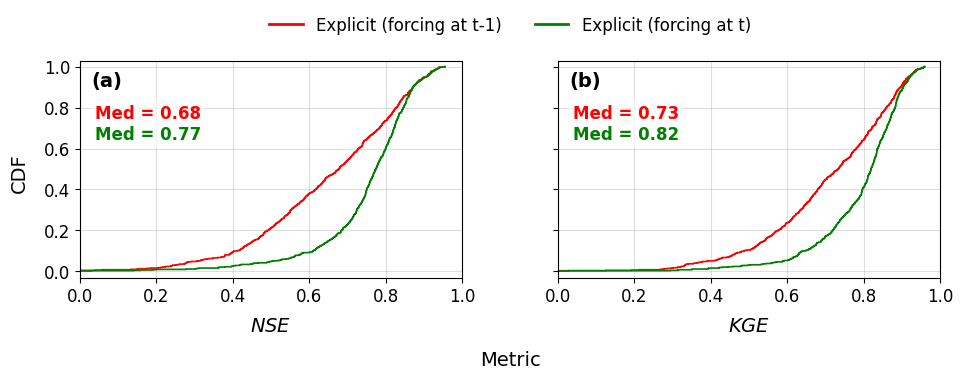

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

models = {
    "Explicit (forcing at t-1)": results_cGRH_exp,
    "Explicit (forcing at t)": results_cGRH_semi_exp
}

colors = ["red", "green"]

metrics = [
    ("NSE_val", r"$NSE$", (0.0, 1.0)),
    ("KGE_val", r"$KGE$", (0.0, 1.0))
]

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 3.5),
    sharey=True
)

axes = axes.flatten()

panel_labels = ["(a)", "(b)"]

for ax, (metric_key, metric_name, xlim), panel in zip(
        axes, metrics, panel_labels):

    stats_text = []

    for (name, res), color in zip(models.items(), colors):

        vals = np.array([
            res[s][metric_key]
            for s in res
            if metric_key in res[s]
            and not np.isnan(res[s][metric_key])
        ])

        if len(vals) == 0:
            continue

        vals_sorted = np.sort(vals)
        cdf = np.arange(1, len(vals_sorted) + 1) / len(vals_sorted)

        x = np.concatenate(([vals_sorted[0]], vals_sorted))
        y = np.concatenate(([0], cdf))

        ax.step(
            x,
            y,
            where="post",
            linewidth=1.2,
            color=color
        )

        # =====================================================
        # Stats (clean + consistent)
        # =====================================================
        stat_val = np.median(vals)
        stat_label = f"Med = {stat_val:.2f}"
        stats_text.append((color, stat_label))

    # =====================================================
    # Panel label
    # =====================================================
    ax.text(
        0.03, 0.95, panel,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    # =====================================================
    # Stats text
    # =====================================================
    y_start = 0.80
    y_step = 0.10

    for k, (color, txt) in enumerate(stats_text):
        ax.text(
            0.04,
            y_start - k * y_step,
            txt,
            color=color,
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
            ha="left",
            va="top",
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                alpha=0.6,
                edgecolor="none"
            )
        )

    # =====================================================
    # Metric label
    # =====================================================
    ax.text(
        0.5, -0.25,
        metric_name,
        transform=ax.transAxes,
        fontsize=14,
        ha="center"
    )

    if xlim is not None:
        ax.set_xlim(*xlim)

    ax.set_ylim(-0.03, 1.03)
    ax.grid(True, alpha=0.4)

    ax.tick_params(axis="both", labelsize=12)

# =====================================================
# GLOBAL SPACING
# =====================================================

fig.subplots_adjust(
    left=0.12,
    right=0.98,
    bottom=0.20,
    top=0.82,
    wspace=0.25
)

# =====================================================
# Shared labels
# =====================================================

fig.text(
    0.05, 0.5,
    "CDF",
    va="center",
    rotation="vertical",
    fontsize=14
)

fig.text(
    0.55, -0.05,
    "Metric",
    ha="center",
    fontsize=14
)

# =====================================================
# Legend
# =====================================================

handles = [
    Line2D([0], [0], color="red", lw=2,
           label="Explicit (forcing at t-1)"),
    Line2D([0], [0], color="green", lw=2,
           label="Explicit (forcing at t)")
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.55, 0.99),
    fontsize=12
)

plt.savefig(
    "im_vs_ex1.jpeg",
    format="jpeg",
    dpi=700,
    bbox_inches="tight"
)

#files.download("im_vs_ex1.jpeg")
plt.show()

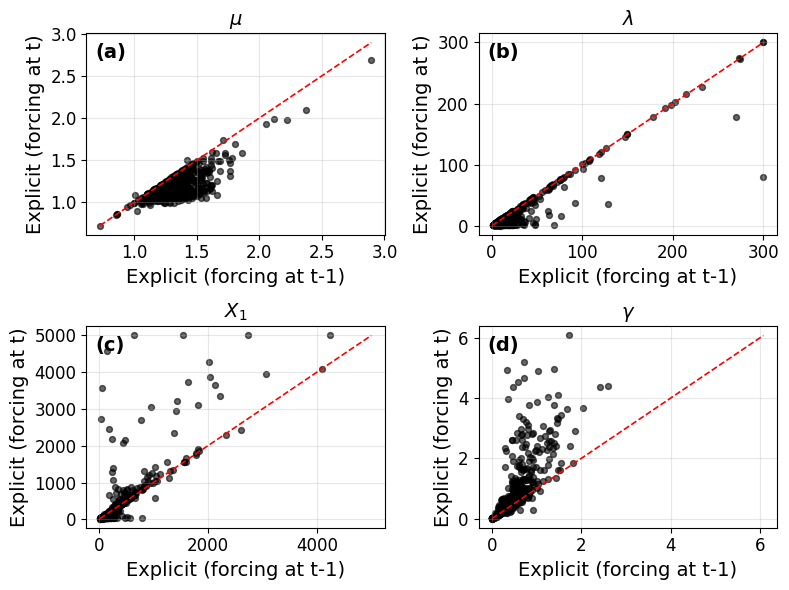

In [ ]:
#Parameters
res1 = results_cGRH_exp
res2 = results_cGRH_semi_exp

param_names = [
    r"$\mu$",
    r"$\lambda$",
    r"$X_1$",
    r"$\gamma$"
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

plt.figure(figsize=(8, 6))

for i in range(4):

    p1 = []
    p2 = []

    for s in res1:

        if ("params" in res1[s] and "params" in res2[s]
            and res1[s]["params"] is not None
            and res2[s]["params"] is not None):

            p1.append(res1[s]["params"][i])
            p2.append(res2[s]["params"][i])

    p1 = np.array(p1)
    p2 = np.array(p2)

    ax = plt.subplot(2, 2, i + 1)

    ax.scatter(
        p1,
        p2,
        s=18,
        alpha=0.6,
        color="black"
    )

    # ligne y = x
    min_v = min(np.min(p1), np.min(p2))
    max_v = max(np.max(p1), np.max(p2))

    ax.plot(
        [min_v, max_v],
        [min_v, max_v],
        "r--",
        linewidth=1.2
    )

    ax.text(
        0.03,
        0.95,
        panel_labels[i],
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top"
    )

    ax.set_title(
        param_names[i],
        fontsize=14
    )

    ax.set_xlabel(
        "Explicit (forcing at t-1)",
        fontsize=14
    )

    ax.set_ylabel(
        "Explicit (forcing at t)",
        fontsize=14
    )

    ax.tick_params(
        axis="both",
        labelsize=12
    )

    ax.grid(
        True,
        alpha=0.3
    )

plt.tight_layout()

plt.savefig(
    "im_vs_ex2.jpeg",
    format="jpeg",
    dpi=700,
    bbox_inches="tight"
)

# files.download("im_vs_ex2.jpeg")

plt.show()